In [1]:
%pip install transformers datasets scikit-learn

In [2]:
import torch # type: ignore
from datasets import load_dataset # type: ignore
from transformers import AutoTokenizer, AutoModelForSequenceClassification # type: ignore
from transformers import TrainingArguments, Trainer # type: ignore
from sklearn.metrics import accuracy_score, f1_score
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [3]:
dataset = load_dataset("ag_news")

print(dataset)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})


In [4]:
small_train = dataset["train"].shuffle(seed=42).select(range(20000))
small_test = dataset["test"].shuffle(seed=42).select(range(2000))

In [5]:
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

def tokenize_function(example):
    return tokenizer(example["text"], padding="max_length", truncation=True)

train_dataset = small_train.map(tokenize_function, batched=True)
test_dataset = small_test.map(tokenize_function, batched=True)

train_dataset = train_dataset.remove_columns(["text"])
test_dataset = test_dataset.remove_columns(["text"])

train_dataset = train_dataset.rename_column("label", "labels")
test_dataset = test_dataset.rename_column("label", "labels")

train_dataset.set_format("torch")
test_dataset.set_format("torch")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/20000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [6]:
model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=4
)

model.to(device)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [7]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = logits.argmax(axis=1)

    return {
        "accuracy": accuracy_score(labels, predictions),
        "f1": f1_score(labels, predictions, average="weighted")
    }

In [8]:
training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=1,
    fp16=True,
    logging_steps=500
)

In [9]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

start_time = time.time()

trainer.train()

end_time = time.time()
print("Training Time (minutes):", (end_time - start_time) / 60)

Step,Training Loss
500,0.374648


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training Time (minutes): 4.436334566275279


In [10]:
results = trainer.evaluate()
print(results)

{'eval_loss': 0.272865355014801, 'eval_accuracy': 0.91, 'eval_f1': 0.9099695857365416, 'eval_runtime': 7.831, 'eval_samples_per_second': 255.394, 'eval_steps_per_second': 8.045, 'epoch': 1.0}


In [11]:
trainer.save_model("news-classifier")
tokenizer.save_pretrained("news-classifier")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('news-classifier/tokenizer_config.json', 'news-classifier/tokenizer.json')

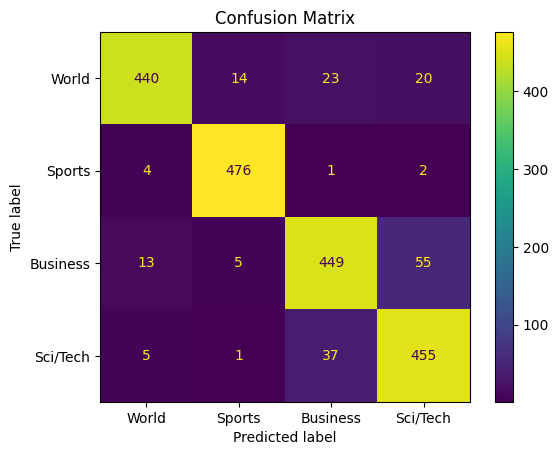

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np


predictions = trainer.predict(test_dataset)
y_true = predictions.label_ids
y_pred = np.argmax(predictions.predictions, axis=1)


labels = ["World", "Sports", "Business", "Sci/Tech"]


cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot()

plt.title("Confusion Matrix")
plt.show()

In [ ]:

id2label = {
    0: "World",
    1: "Sports",
    2: "Business",
    3: "Sci/Tech",
}

def predict_news(text: str):
    model.eval()
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128,
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.softmax(outputs.logits, dim=1)
        pred_id = int(torch.argmax(probs, dim=1).item())
        confidence = float(probs[0, pred_id].item())

    return id2label[pred_id], confidence


user_text = "Apple releases new iPhone with groundbreaking features"

pred_label, pred_conf = predict_news(user_text)
print(f"Predicted class: {pred_label}")
print(f"Confidence: {pred_conf:.2%}")

Predicted class: Sci/Tech
Confidence: 93.72%


In [17]:
user_text= "Ronaldo scores hat-trick in Champions League final"
pred_label, pred_conf = predict_news(user_text)
print(f"Predicted class: {pred_label}")
print(f"Confidence: {pred_conf:.2%}")

Predicted class: Sports
Confidence: 96.51%


In [16]:
user_text= "Iran opens state of hormuz"
pred_label, pred_conf = predict_news(user_text)
print(f"Predicted class: {pred_label}")
print(f"Confidence: {pred_conf:.2%}")

Predicted class: World
Confidence: 97.98%


In [19]:
user_text= "Tesla announces record-breaking quarterly earnings"
pred_label, pred_conf = predict_news(user_text)
print(f"Predicted class: {pred_label}")
print(f"Confidence: {pred_conf:.2%}")

Predicted class: Business
Confidence: 95.06%
